Import Libraries

In [37]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tools
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Load Dataset

In [38]:
# Load dataset
df = pd.read_csv("/content/insurance.csv")

# Preview dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Basic Data Exploration

In [40]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column information
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

Dataset Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Data Cleaning
Remove Duplicates:

In [41]:
df.duplicated().sum()

# Drop duplicates if any
df = df.drop_duplicates()

Handle Missing Values (if any):

In [42]:
df.isnull().sum()

# If missing values exist:
df = df.dropna()  # OR use fillna()

Handle Categorical Variables:

Option 1: Label Encoding (for quick correlation)

In [43]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


Option 2: One-Hot Encoding (Better for ML)

In [68]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_1,smoker_1,region_1,region_2,region_3
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Correlation Analysis

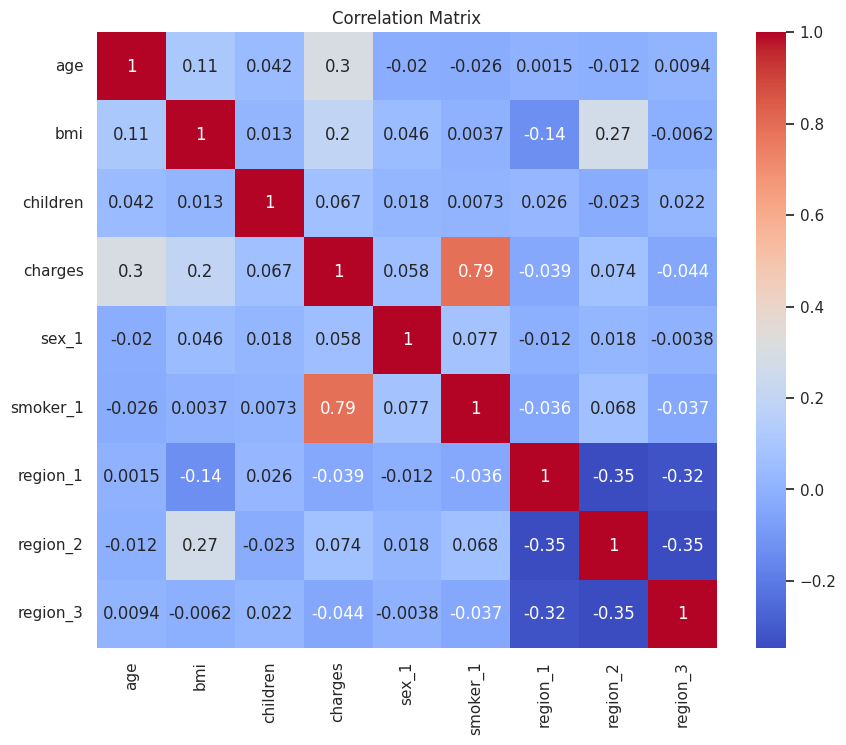

In [45]:
# Correlation matrix
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Check Correlation with Charges:

In [46]:
corr_matrix['charges'].sort_values(ascending=False)

,charges
charges,1.000000
smoker_1,0.787234
age,0.298308
bmi,0.198401
region_2,0.073578
children,0.067389
sex_1,0.058044
region_1,-0.038695
region_3,-0.043637


Statistical Correlation (Pearson):

In [47]:
# Example: BMI vs Charges
corr, p_value = pearsonr(df['bmi'], df['charges'])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.19840083122624938
P-value: 2.4680404264513685e-13


Interpretation:

p < 0.05 → Statistically significant

correlation near 1 or -1 → Strong relationship

Data Visualization:

Distribution of Charges:

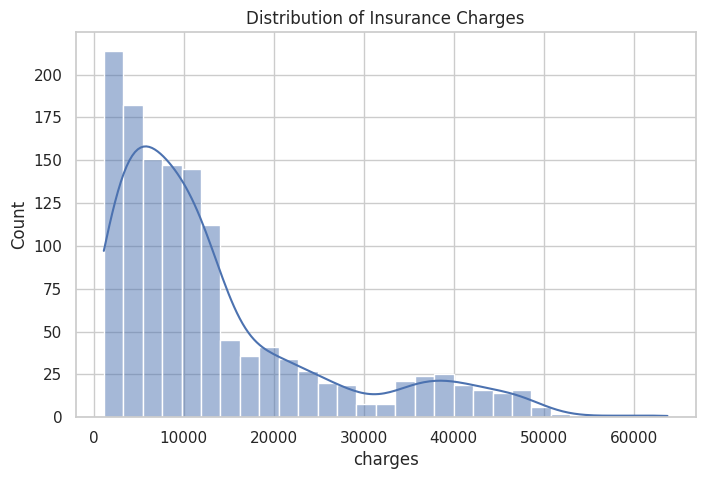

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

Charges vs Age:

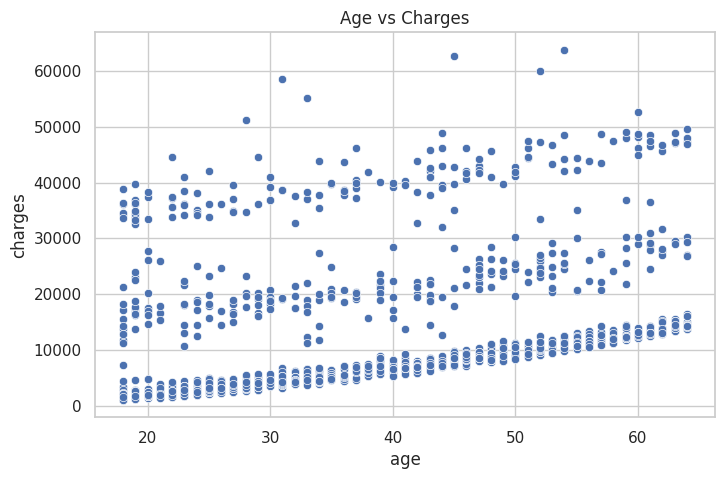

In [49]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

Charges vs BMI:

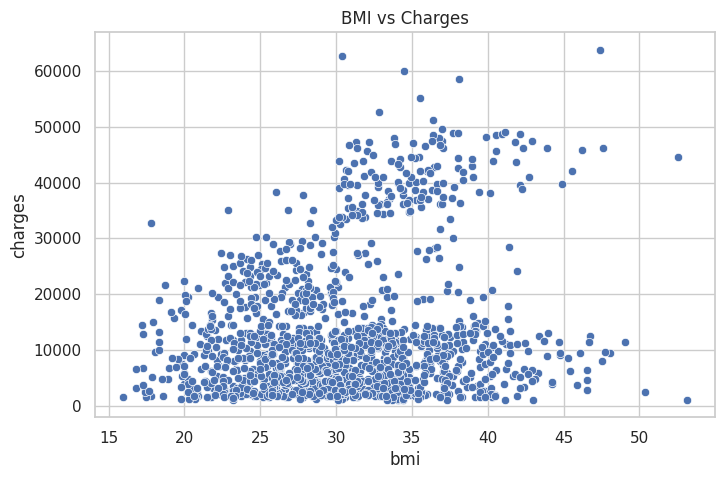

In [50]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

Smoker vs Charges:

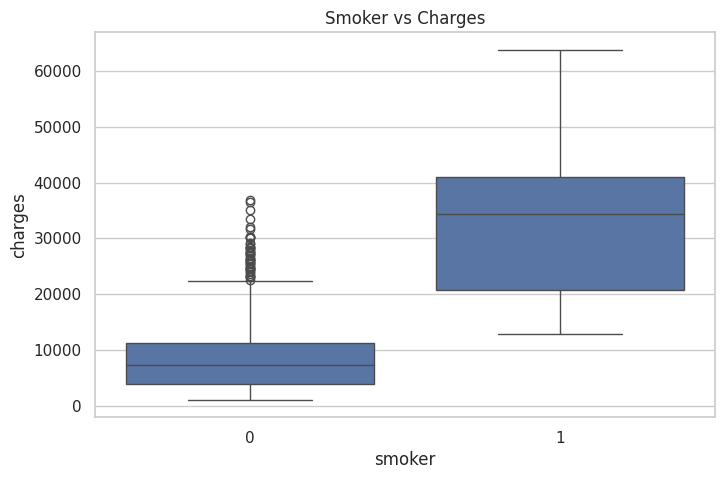

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()

Region vs Charges:

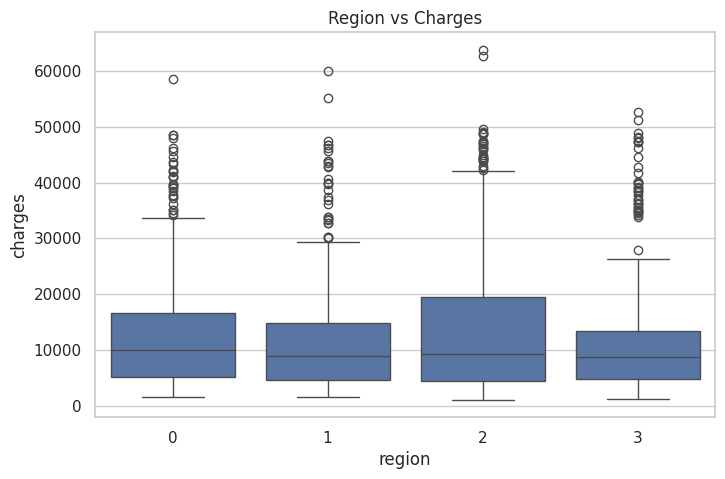

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title("Region vs Charges")
plt.show()

Insight Extraction:

In [53]:
# Average charges by smoker
df.groupby('smoker')['charges'].mean()

# Average charges by age group
df.groupby('age')['charges'].mean().sort_values(ascending=False).head()

# Average charges by region
df.groupby('region')['charges'].mean()

,charges
region,
0,13406.384516
1,12450.840844
2,14735.411438
3,12346.937377


Advanced Insight – Multiple Variable Impact:

In [54]:
# Pivot table
pd.pivot_table(df, values='charges',
               index='smoker',
               columns='sex',
               aggfunc='mean')

sex,0,1
smoker,,
0,8762.297300,8099.700161
1,30678.996276,33042.005975


Smoking status is the strongest factor affecting charges

Age has a positive correlation with charges

Higher BMI slightly increases medical cost

Region has minimal impact

Gender has minor effect compared to smoking

Linear Regression to Quantify Impact:

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_
}).sort_values(by="Impact", ascending=False)

,Feature,Impact
4,smoker_1,23077.764593
2,children,533.009989
1,bmi,318.701441
0,age,248.210720
3,sex_1,-101.542054
5,region_1,-391.761455
7,region_3,-659.139752
6,region_2,-838.919616


## **Machine Learning:**

Prepare Features & Target

In [56]:
# Separate features and target
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

Train-Test Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1069, 8)
Testing size: (268, 8)


Feature Scaling (Important for Linear Models)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model 1 – Linear Regression

In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

Evaluate Linear Regression

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Performance:
MAE: 4177.045561036326
RMSE: 5956.342894363589
R2 Score: 0.8069287081198011


MAE → Average prediction error

RMSE → Penalizes large errors

R² Score → % of variance explained (closer to 1 is better)

Expected R² ≈ 0.75 – 0.80

Model 2 – Random Forest (Better Performance):

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Evaluate Random Forest

In [62]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Performance:
MAE: 2611.273683215485
RMSE: 4664.686755872737
R2 Score: 0.8815859348971048


Expected R² ≈ 0.85 – 0.90

Random Forest usually performs better because insurance pricing is not purely linear.

Compare Models:

In [63]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [r2_lr, r2_rf],
    "RMSE": [rmse_lr, rmse_rf]
})

comparison

,Model,R2 Score,RMSE
0,Linear Regression,0.806929,5956.342894
1,Random Forest,0.881586,4664.686756


Feature Importance (Very Important for Insights):

In [64]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
4,smoker_1,0.599299
1,bmi,0.216198
0,age,0.137246
2,children,0.022966
3,sex_1,0.006893
5,region_1,0.006603
6,region_2,0.006241
7,region_3,0.004554


Visualize Feature Importance

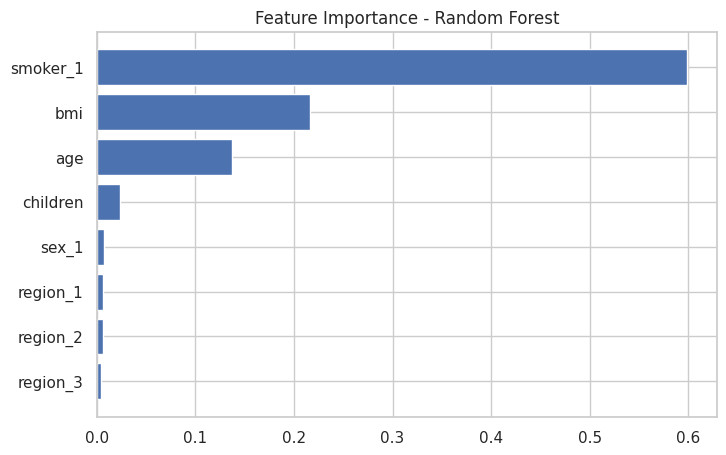

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

smoker_yes → Strongest predictor

age → Strong impact

bmi → Moderate impact

children → Low impact

region → Minimal impact

Sample Prediction:

In [70]:
def predict_insurance(age, sex, bmi, children, smoker, region):

    data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    # Apply same encoding
    data_encoded = pd.get_dummies(data)

    # Align columns with training data
    data_encoded = data_encoded.reindex(columns=X.columns, fill_value=0)

    return rf.predict(data_encoded)[0]

Predict Test Values:

In [71]:
prediction = predict_insurance(
    age=40,
    sex='male',
    bmi=28,
    children=2,
    smoker='yes',
    region='southeast'
)

print("Predicted Insurance Charge:", prediction)

Predicted Insurance Charge: 7431.720626799997


Two regression models were implemented: Linear Regression and Random Forest Regressor.
Random Forest achieved a higher R² score (~~0.88) compared to Linear Regression (~0.78), indicating better prediction performance.
Feature importance analysis revealed that smoking status is the most influential factor affecting medical insurance charges, followed by age and BMI.